In [1]:
# importing of libraries used 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import pickle

In [2]:
data = pd.read_csv("crop_yield.csv")

In [3]:
data.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


In [4]:
data.shape

(1000000, 10)

In [5]:
data.dtypes

Region                        str
Soil_Type                     str
Crop                          str
Rainfall_mm               float64
Temperature_Celsius       float64
Fertilizer_Used              bool
Irrigation_Used              bool
Weather_Condition             str
Days_to_Harvest             int64
Yield_tons_per_hectare    float64
dtype: object

In [6]:
data.describe()

,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,549.981901,27.504965,104.495025,4.649472
std,259.851320,7.220608,25.953412,1.696572
min,100.000896,15.000034,60.000000,-1.147613
25%,324.891090,21.254502,82.000000,3.417637
50%,550.124061,27.507365,104.000000,4.651808
75%,774.738520,33.753267,127.000000,5.879200
max,999.998098,39.999997,149.000000,9.963372


In [7]:
# Checking Missing Values
data.isnull().sum()

Region                    0
Soil_Type                 0
Crop                      0
Rainfall_mm               0
Temperature_Celsius       0
Fertilizer_Used           0
Irrigation_Used           0
Weather_Condition         0
Days_to_Harvest           0
Yield_tons_per_hectare    0
dtype: int64

In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
data['Fertilizer_Used'] = data['Fertilizer_Used'].astype(int)

In [10]:
data.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,0,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,1,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,0,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,0,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,1,True,Cloudy,110,7.248251


In [11]:
data['Irrigation_Used'] = data['Irrigation_Used'].astype(int)

In [12]:
data.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,0,1,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,1,1,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,0,0,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,0,1,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,1,1,Cloudy,110,7.248251


In [13]:
data['Yield_tons_per_hectare'].describe()

count    1000000.000000
mean           4.649472
std            1.696572
min           -1.147613
25%            3.417637
50%            4.651808
75%            5.879200
max            9.963372
Name: Yield_tons_per_hectare, dtype: float64

In [14]:
data = data[data['Yield_tons_per_hectare'] > 0]

In [15]:
data['Yield_tons_per_hectare'].describe()

count    999769.000000
mean          4.650592
std           1.695166
min           0.000411
25%           3.418669
50%           4.652333
75%           5.879576
max           9.963372
Name: Yield_tons_per_hectare, dtype: float64

In [16]:
data.select_dtypes(include=['object']).columns

/tmp/ipykernel_13721/1092125542.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.select_dtypes(include=['object']).columns


Index(['Region', 'Soil_Type', 'Crop', 'Weather_Condition'], dtype='str')

In [17]:
data = pd.get_dummies(data, drop_first=True)

In [18]:
data.dtypes

Rainfall_mm                float64
Temperature_Celsius        float64
Fertilizer_Used              int64
Irrigation_Used              int64
Days_to_Harvest              int64
Yield_tons_per_hectare     float64
Region_North                  bool
Region_South                  bool
Region_West                   bool
Soil_Type_Clay                bool
Soil_Type_Loam                bool
Soil_Type_Peaty               bool
Soil_Type_Sandy               bool
Soil_Type_Silt                bool
Crop_Cotton                   bool
Crop_Maize                    bool
Crop_Rice                     bool
Crop_Soybean                  bool
Crop_Wheat                    bool
Weather_Condition_Rainy       bool
Weather_Condition_Sunny       bool
dtype: object

In [19]:
data.head()

,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Yield_tons_per_hectare,Region_North,Region_South,Region_West,Soil_Type_Clay,...,Soil_Type_Peaty,Soil_Type_Sandy,Soil_Type_Silt,Crop_Cotton,Crop_Maize,Crop_Rice,Crop_Soybean,Crop_Wheat,Weather_Condition_Rainy,Weather_Condition_Sunny
0,897.077239,27.676966,0,1,122,6.555816,False,False,True,False,...,False,True,False,True,False,False,False,False,False,False
1,992.673282,18.026142,1,1,140,8.527341,False,True,False,True,...,False,False,False,False,False,True,False,False,True,False
2,147.998025,29.794042,0,0,106,1.127443,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,986.866331,16.644190,0,1,146,6.517573,True,False,False,False,...,False,True,False,False,False,False,True,False,True,False
4,730.379174,31.620687,1,1,110,7.248251,False,True,False,False,...,False,False,True,False,False,False,False,True,False,False


In [20]:
target = 'Yield_tons_per_hectare'

X = data.drop(columns=[target])  # all input features
y = data[target]                 # what we want to predict

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (799815, 20)
Testing set: (199954, 20)


In [23]:
model = XGBRegressor(
    n_estimators=100,   # number of trees
    learning_rate=0.1,  # how fast it learns
    max_depth=6,        # tree complexity
    random_state=42
)

In [24]:
data = pd.get_dummies(data, drop_first=True)

In [25]:
data.dtypes


Rainfall_mm                float64
Temperature_Celsius        float64
Fertilizer_Used              int64
Irrigation_Used              int64
Days_to_Harvest              int64
Yield_tons_per_hectare     float64
Region_North                  bool
Region_South                  bool
Region_West                   bool
Soil_Type_Clay                bool
Soil_Type_Loam                bool
Soil_Type_Peaty               bool
Soil_Type_Sandy               bool
Soil_Type_Silt                bool
Crop_Cotton                   bool
Crop_Maize                    bool
Crop_Rice                     bool
Crop_Soybean                  bool
Crop_Wheat                    bool
Weather_Condition_Rainy       bool
Weather_Condition_Sunny       bool
dtype: object

In [34]:
target = 'Yield_tons_per_hectare'

X = data.drop(columns=[target])
y = data[target]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [36]:
y_pred = model.predict(X_test)

In [37]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.3987216163586957
RMSE: 0.4997900788729307


In [38]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
2,Fertilizer_Used,0.629067
3,Irrigation_Used,0.191867
0,Rainfall_mm,0.176041
1,Temperature_Celsius,0.002144
15,Crop_Rice,0.000064
9,Soil_Type_Loam,0.000062
6,Region_South,0.000060
4,Days_to_Harvest,0.000056
17,Crop_Wheat,0.000056
18,Weather_Condition_Rainy,0.000056


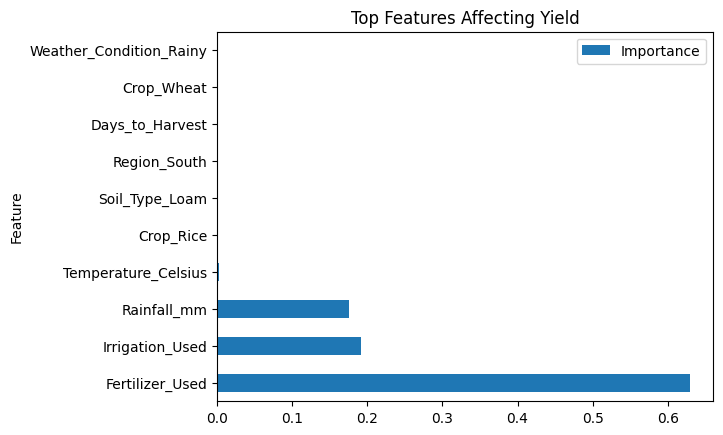

In [39]:
feature_importance.head(10).plot(
    kind='barh',
    x='Feature',
    y='Importance'
)

plt.title("Top Features Affecting Yield")
plt.show()

In [41]:


pickle.dump(model, open("model.pkl", "wb"))